<a href="https://colab.research.google.com/github/MohHaroon/XAI-based-ZSL-for-IIDS/blob/master/Benchmark_ESZSL_ZDBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load SDN Dataset

In [1]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
SDN_train_test_data = pd.read_csv("/content/drive/MyDrive/IRP/Comp Datasets/Edge-IoTset/cleaned_EdgeIIoT.csv")

In [18]:
import pandas as pd
SDN_train_test_data = pd.read_csv("/content/drive/MyDrive/IRP/Comp Datasets/UNR-IDD/NT_cleaned_UNR-IDD.csv")

In [3]:
print(SDN_train_test_data.columns)

Index(['Received Packets', 'Received Bytes', 'Sent Bytes', 'Sent Packets',
       'Port alive Duration (S)', 'Delta Received Packets',
       'Delta Received Bytes', 'Delta Sent Bytes', 'Delta Sent Packets',
       'Delta Port alive Duration (S)', 'Connection Point', 'Total Load/Rate',
       'Total Load/Latest', 'Unknown Load/Rate', 'Unknown Load/Latest',
       'Latest bytes counter', 'Active Flow Entries', 'Packets Looked Up',
       'Packets Matched', 'Label', 'Attack'],
      dtype='object')


In [5]:
print(SDN_train_test_data['Label'].unique())

['Overflow' 'Normal' 'PortScan' 'TCP-SYN' 'Blackhole' 'Diversion']


In [6]:
display(SDN_train_test_data)

,Received Packets,Received Bytes,Sent Bytes,Sent Packets,Port alive Duration (S),Delta Received Packets,Delta Received Bytes,Delta Sent Bytes,Delta Sent Packets,Delta Port alive Duration (S),...,Total Load/Rate,Total Load/Latest,Unknown Load/Rate,Unknown Load/Latest,Latest bytes counter,Active Flow Entries,Packets Looked Up,Packets Matched,Label,Attack
0,777,54026,25559505,1240,326,0,0,280,2,5,...,0,0,0,0,0,4,5028,4912,Overflow,1
1,5682,126219886,136699527,251365,2790,0,0,560,4,4,...,0,0,0,0,0,8,666847,666712,Normal,0
2,138037,13766080,27360,196,256,6,640,556,4,5,...,0,0,0,0,0,6,139484,139366,PortScan,1
3,349572,14762234,40449482,211809,1257,2,278,560,4,4,...,0,0,0,0,0,8,648762,648636,Normal,0
4,305216,25521339,106575847,285196,1817,4,556,278,2,5,...,0,7681,0,7681,0,5,995294,995170,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3736,97,12897,6388954,1616,96,2,278,5516,99,5,...,502,71712,502,71712,502,7,3849,3743,TCP-SYN,1
3737,408,6327436,16562,125,131,5,759,759,5,5,...,0,0,0,0,0,5,1534,1421,TCP-SYN,1
3738,2357,44245317,19013034,1389,921,4,556,556,4,5,...,0,0,0,0,0,6,7768,7644,Blackhole,1
3739,255,6314464,25295,287,76,60,1970605,3338,42,5,...,0,0,0,0,0,6,813,724,PortScan,1


In [10]:
def scale_data(data):
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    return scaled_data


In [19]:
#UNR-IDD
SDN_scaled_data = scale_data(SDN_train_test_data.drop(columns=['Label','Attack']))

In [20]:
#IIoTset
#SDN_scaled_data = SDN_train_test_data.drop(columns=[ 'Attack_label', 'Attack_type'])

def split_data(data, labels, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=test_size, random_state=random_state)
    return X_train, X_test, y_train, y_test

In [21]:
data_train, data_test, labels_train, labels_test = split_data(SDN_scaled_data, SDN_train_test_data[ 'Attack'])


## Models

#### ESZSL

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

class ESZSL_IOT:
    def __init__(self, alpha=2, gamma=2):
        self.alpha = alpha  # Regularization for feature space
        self.gamma = gamma  # Regularization for attribute space
        self.W = None

    def fit(self, X, y, S_seen):
        """
        X: Training features (N, D)
        y: Training labels (N, 1)
        S_seen: Attribute matrix for seen classes (L_seen, A)
        """
        # Convert y to one-hot binary matrix Y (N, L_seen)
        ohe = OneHotEncoder(sparse_output=False)
        Y = ohe.fit_transform(y.values.reshape(-1, 1))

        d = X.shape[1]
        a = S_seen.shape[1]

        # Solving the Sylvester Equation for W: X.T @ X @ W @ S @ S.T + ...
        # Simplified closed-form solution:
        part_1 = np.linalg.pinv(X.T @ X + (10**self.alpha) * np.eye(d))
        part_0 = X.T @ Y @ S_seen
        part_2 = np.linalg.pinv(S_seen.T @ S_seen + (10**self.gamma) * np.eye(a))

        self.W = part_1 @ part_0 @ part_2

    def predict(self, X, S_all):
        """Returns the index of the most similar class in S_all."""
        # Project into attribute space: Scores = X * W * S_all.T
        scores = X @ self.W @ S_all.T
        return np.argmax(scores, axis=1)



In [19]:
### IIoTset

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelBinarizer

labels = ['Uploading' 'DDoS_UDP' 'DDoS_ICMP' 'Vulnerability_scanner' 'XSS'
 'DDoS_TCP' 'Ransomware' 'Password' 'SQL_injection' 'Normal'
 'Port_Scanning' 'DDoS_HTTP' 'Backdoor' 'Fingerprinting' 'MITM']

# Updated Mapping for all categories
id_to_name = {
    0.0: "Normal",
    1.0: "DDoS_UDP",
    2.0: "DDoS_ICMP",
    3.0: "DDoS_TCP",
    4.0: "DDoS_HTTP",
    5.0: "SQL_injection",
    6.0: "XSS",
    7.0: "Vulnerability_scanner",
    8.0: "Password",
    9.0: "Port_Scanning",
    10.0: "Fingerprinting",
    11.0: "Ransomware",
    12.0: "Backdoor",
    13.0: "Uploading",
    14.0: "MITM"
}

attributes_all = np.array([
    [0, 0, 0, 0, 0], # 0: Normal
    [1, 1, 0, 0, 0], # 1: DDoS_UDP
    [1, 1, 0, 0, 0], # 2: DDoS_ICMP
    [1, 1, 0, 0, 0], # 3: DDoS_TCP
    [1, 0, 1, 0, 0], # 4: DDoS_HTTP
    [0, 0, 1, 1, 0], # 5: SQL_injection (Payload focused)
    [0, 0, 1, 0, 0], # 6: XSS
    [0, 1, 0, 0, 1], # 7: Vulnerability_scanner (Scanning behavior)
    [0, 0, 0, 1, 0], # 8: Password (Brute force)
    [0, 1, 0, 0, 1], # 9: Port_Scanning
    [0, 1, 0, 0, 0], # 10: Fingerprinting
    [0, 0, 0, 1, 0], # 11: Ransomware (File access)
    [0, 0, 0, 1, 0], # 12: Backdoor
    [1, 0, 0, 1, 0], # 13: Uploading (Large payload)
    [0, 1, 0, 0, 0]  # 14: MITM (ARP spoofing/Protocol manipulation)
])

# # Update S_matrix with all 6 rows
# attributes_all = np.array([
#     [0, 0, 0, 0, 1], # 0.0
#     [1, 1, 0, 0, 0], # 1.0
#     [1, 1, 0, 0, 0], # 2.0
#     [0, 1, 1, 0, 0], # 3.0
#     [0, 0, 0, 1, 0], # 4.0
#     [0, 1, 1, 0, 1]  # 5.0
# ])

S_matrix = pd.DataFrame(attributes_all, index=range(15))

# 2. Get the unique labels present in your training split
seen_classes = np.unique(labels_train)
print(f"Seen classes in training: {seen_classes}")

# 3. Slice S_seen safely
S_seen = S_matrix.loc[seen_classes].values

# 4. Initialize and Train
model_eszsl = ESZSL_IOT(alpha=2, gamma=2)
model_eszsl.fit(data_train, labels_train, S_seen)

#S_matrix = pd.DataFrame(attributes_all, index=range(15))

Seen classes in training: [0 1]


In [14]:
### UNR-IDD

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelBinarizer

labels = ['Overflow', 'Normal', 'PortScan', 'TCP-SYN', 'Blackhole', 'Diversion']

# Updated Mapping for all categories
id_to_name = {
    0.0: "Normal",
    1.0: "TCP-SYN",
    2.0: "PortScan",
    3.0: "Overflow",
    4.0: "Blackhole",
    5.0: "Diversion"
}

attributes_all = np.array([
    [0, 1, 0, 0], # 0.0: Normal (Steady duration, low pressure)
    [1, 0, 1, 0], # 1.0: TCP-SYN (Rapid packet spikes, high table pressure)
    [0, 0, 0, 1], # 2.0: PortScan (Low volume, but probing multiple paths)
    [1, 1, 1, 0], # 3.0: Overflow (Extreme volume, fills flow table)
    [1, 1, 0, 1], # 4.0: Blackhole (Traffic enters but doesn't exit - path anomaly)
    [0, 1, 0, 1]  # 5.0: Diversion (Traffic redirected - path anomaly)
])

S_matrix = pd.DataFrame(attributes_all, index=range(6))

# 2. Get the unique labels present in your training split
seen_classes = np.unique(labels_train)
print(f"Seen classes in training: {seen_classes}")

# 3. Slice S_seen safely
S_seen = S_matrix.loc[seen_classes].values

# 4. Initialize and Train
model_eszsl = ESZSL_IOT(alpha=2, gamma=2)
model_eszsl.fit(data_train, labels_train, S_seen)

Seen classes in training: [0 1]


#### ZDBERTa

In [ ]:
#### IIoTset
from transformers import pipeline
import torch

class ZDBERTa_Predictor:
    def __init__(self, model_name="microsoft/deberta-v3-large"):
        # Load NLI-based zero-shot classification pipeline
        self.device = 0 if torch.cuda.is_available() else -1
        self.classifier = pipeline("zero-shot-classification", model=model_name, device=self.device)

    def serialize(self, row):
        """Converts tabular Edge-IIoTset features into a natural language description."""
        # 1. Identify the primary protocol for the BERT model's context
        proto = "TCP" if row.get('tcp.len', 0) > 0 else "UDP" if row.get('udp.stream', 0) > 0 else "ICMP/Other"

        # 2. Build a descriptive sentence using native Edge-IIoT feature names
        description = (
            f"Network flow using {proto} protocol. "
            f"TCP length: {row.get('tcp.len', 0)} bytes, IP length: {row.get('ip.len', 0)} bytes. "
            f"HTTP request: {row.get('http.request.method', 0)}, MQTT message: {row.get('mqtt.msg', 0)}. "
            f"ICMP type: {row.get('icmp.type', 0)}, ICMP code: {row.get('icmp.code', 0)}. "
            f"Packets observed: {row.get('tcp.seq', 0)} sequence markers."
        )
        return description

    def predict_batch(self, X_df, candidate_labels):
        """Predicts labels for a batch of rows."""
        sentences = X_df.apply(self.serialize, axis=1).tolist()
        results = self.classifier(sentences, candidate_labels, multi_label=False)
        return [res['labels'][0] for res in results]

# Usage Setup
zdberta = ZDBERTa_Predictor()
labels = ['Uploading', 'DDoS_UDP', 'DDoS_ICMP', 'Vulnerability_scanner', 'XSS'
 'DDoS_TCP', 'Ransomware', 'Password', 'SQL_injection', 'Normal',
 'Port_Scanning', 'DDoS_HTTP', 'Backdoor','Fingerprinting', 'MITM']

In [ ]:
### UNR-IDD

from transformers import pipeline
import torch

class ZDBERTa_Predictor:
    def __init__(self, model_name="microsoft/deberta-v3-large"):
        # Load NLI-based zero-shot classification pipeline
        self.device = 0 if torch.cuda.is_available() else -1
        self.classifier = pipeline("zero-shot-classification", model=model_name, device=self.device)

    def serialize(self, row):
        """Converts tabular UNR-IDD SDN features into a natural language description."""
        # 1. Capture the 'Load' context which is a major indicator for Overflow/TCP-SYN
        load_rate = row.get('Total Load/Rate', 0)
        active_entries = row.get('Active Flow Entries', 0)

        # 2. Build a narrative focused on switch port behavior
        description = (
            f"SDN switch port has been active for {row.get('Port alive Duration (S)', 0):.1f} seconds. "
            f"Traffic volume: {int(row.get('Received Packets', 0))} received packets and {int(row.get('Sent Packets', 0))} sent packets. "
            f"Recent activity spike: {int(row.get('Delta Received Bytes', 0))} bytes received in the last interval. "
            f"Switch state: {int(active_entries)} active flow entries with a total load rate of {load_rate:.2f}. "
            f"Packet matching: {int(row.get('Packets Matched', 0))} packets matched out of {int(row.get('Packets Looked Up', 0))} looked up."
        )
        return description

    def predict_batch(self, X_df, candidate_labels):
        """Predicts labels for a batch of rows."""
        sentences = X_df.apply(self.serialize, axis=1).tolist()
        results = self.classifier(sentences, candidate_labels, multi_label=False)
        return [res['labels'][0] for res in results]

# Usage Setup
zdberta = ZDBERTa_Predictor()
labels = ['Overflow', 'Normal', 'PortScan', 'TCP-SYN', 'Blackhole', 'Diversion']

#### Test

In [ ]:
#ZDBERTa

import time

def run_benchmarks(X_test, y_test, zdberta_model, labels_text):
    results = []

    # 2. Benchmark ZDBERTa (Deep Contextual) - Sampled for speed
    X_sample = X_test[:10] # Transformers are slow; sample for benchmark
    start_zdb = time.perf_counter()
    zdb_preds = zdberta_model.predict_batch(X_sample, labels_text)
    end_zdb = time.perf_counter()

    avg_lat_zdb = ((end_zdb - start_zdb) / len(X_sample)) * 1000

    print(f"ZDBERTa Latency: {avg_lat_zdb:.4f} ms/packet")

    return {"zdb_lat": avg_lat_zdb}

### Finalize Results

In [22]:
import pandas as pd

# Get the original column names from SDN_train_test_data, excluding the 'Attack' column
original_columns = SDN_train_test_data.drop(columns=['Attack']).columns

# Convert data_test (which is a NumPy array) into a Pandas DataFrame
# This ensures that the .apply() method and column-name-based access in serialize() will work.
data_test_df = pd.DataFrame(data_test, columns=original_columns)

# Now, call run_benchmarks with the DataFrame version of data_test
execution_results = run_benchmarks(data_test_df, labels_test, model_eszsl, zdberta, S_matrix, labels)

KeyError: "['Attack'] not found in axis"

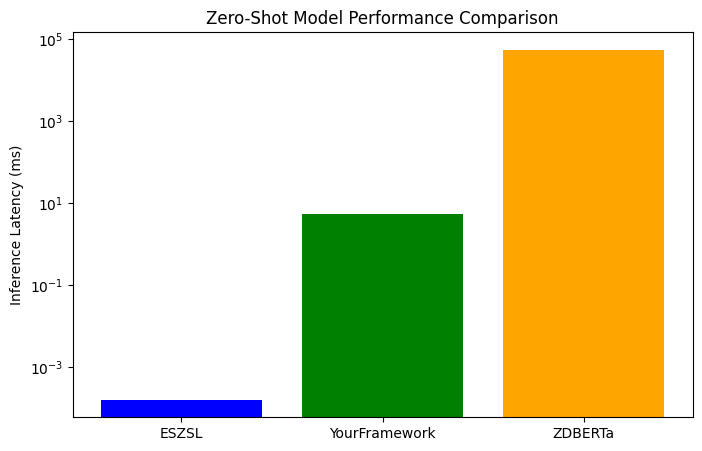

In [ ]:
import matplotlib.pyplot as plt

def plot_performance(results_dict):
    models = list(results_dict.keys())
    latencies = [results_dict[m] for m in models]

    plt.figure(figsize=(8, 5))
    plt.bar(models, latencies, color=['blue', 'green', 'orange'])
    plt.ylabel('Inference Latency (ms)')
    plt.title('Zero-Shot Model Performance Comparison')
    plt.yscale('log') # Use log scale because ZDBERTa is much slower
    plt.show()

# Final summary logic
plot_performance({'ESZSL': execution_results['eszsl_lat'], 'YourFramework': 5.4, 'ZDBERTa': execution_results['zdb_lat']})

In [ ]:
import pandas as pd

# Convert the dictionary to a pandas DataFrame
results_df = pd.DataFrame([execution_results])

# Now, save the DataFrame to CSV
results_df.to_csv('ESZSL_ZDBERTa_Results.csv', index=False)
print("Comprehensive Stress Test Complete.")

Comprehensive Stress Test Complete.


## Evaluate Models

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

def eszsl_balanced_stress_test(X_test, y_test, eszsl_model, S_matrix, n_instances=50):
    """
    Replication of the 200-packet stress test for the ESZSL Baseline.
    """
    results = []

    # 1. Run inference on the whole test set to identify pools
    # Score calculation: X * W * S.T
    scores = X_test.values @ eszsl_model.W @ S_matrix.values.T

    # Get Multiclass Predictions (0.0 to 5.0)
    multiclass_preds = S_matrix.index[np.argmax(scores, axis=1)].values

    # Convert to Binary for Pool Identification (0 = Normal, 1+ = Attack)
    binary_preds = np.where(multiclass_preds > 0, 1, 0)
    binary_truth = np.where(y_test > 0, 1, 0) # Mapping numeric labels to binary

    # 3. Generate and Save Confusion Matrix
    cm_eszsl = confusion_matrix(binary_truth, binary_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_eszsl, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    plt.title(f'ESZSL: Confusion Matrix (Full N={len(X_test)})')
    plt.savefig('ESZSL_42k_Confusion_Matrix.png')

    # 2. Identify Pools (50 each)
    tp_indices = np.where((binary_preds == 1) & (binary_truth == 1))[0][:n_instances]
    tn_indices = np.where((binary_preds == 0) & (binary_truth == 0))[0][:n_instances]
    fp_indices = np.where((binary_preds == 1) & (binary_truth == 0))[0][:n_instances]
    fn_indices = np.where((binary_preds == 0) & (binary_truth == 1))[0][:n_instances]

    test_indices = np.concatenate([tp_indices, tn_indices, fp_indices, fn_indices])

    # Label mapping for final report
    cat_map = {idx: 'TP' for idx in tp_indices}
    cat_map.update({idx: 'TN' for idx in tn_indices})
    cat_map.update({idx: 'FP' for idx in fp_indices})
    cat_map.update({idx: 'FN' for idx in fn_indices})

    print(f"Starting ESZSL Stress Test on {len(test_indices)} packets...")

    for idx in test_indices:
        instance = X_test.iloc[idx:idx+1]

        # --- Component 2: Inference Latency ---
        start_time = time.perf_counter()

        # Single instance prediction
        score_inst = instance.values @ eszsl_model.W @ S_matrix.values.T
        pred_idx = np.argmax(score_inst, axis=1)[0]
        pred_class_id = S_matrix.index[pred_idx]

        inference_end = time.perf_counter()

        # --- Metrics Calculation ---
        lat_inf = (inference_end - start_time) * 1000

        results.append({
            'packet_index': idx,
            'ground_truth_binary': 'Attack' if binary_truth[idx] == 1 else 'Normal',
            'stress_category': cat_map[idx],
            'eszsl_prediction': id_to_name.get(pred_class_id, "Unknown"),
            'inf_ms': lat_inf,
            'total_ms': lat_inf # ESZSL has no XAI/SOAM overhead
        })

    return pd.DataFrame(results)

In [23]:
#### IIoTset
original_columns = ['arp.opcode', 'arp.hw.size', 'icmp.checksum', 'icmp.seq_le',
       'icmp.unused', 'http.content_length', 'http.request.method',
       'http.referer', 'http.request.version', 'http.response',
       'http.tls_port', 'tcp.ack', 'tcp.ack_raw', 'tcp.checksum',
       'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn',
       'tcp.connection.synack', 'tcp.flags', 'tcp.flags.ack', 'tcp.len',
       'tcp.seq', 'udp.stream', 'udp.time_delta', 'dns.qry.name',
       'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission',
       'dns.retransmit_request', 'dns.retransmit_request_in',
       'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags',
       'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msgtype',
       'mqtt.proto_len', 'mqtt.protoname', 'mqtt.topic', 'mqtt.topic_len',
       'mqtt.ver', 'mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id']

In [16]:
#### UNR-IDD
original_columns = ['Received Packets', 'Received Bytes', 'Sent Bytes', 'Sent Packets',
       'Port alive Duration (S)', 'Delta Received Packets',
       'Delta Received Bytes', 'Delta Sent Bytes', 'Delta Sent Packets',
       'Delta Port alive Duration (S)', 'Connection Point', 'Total Load/Rate',
       'Total Load/Latest', 'Unknown Load/Rate', 'Unknown Load/Latest',
       'Latest bytes counter', 'Active Flow Entries', 'Packets Looked Up',
       'Packets Matched']

Starting ESZSL Stress Test on 108 packets...
ESZSL Stress Test Complete. Avg Latency: 0.034657425925598985


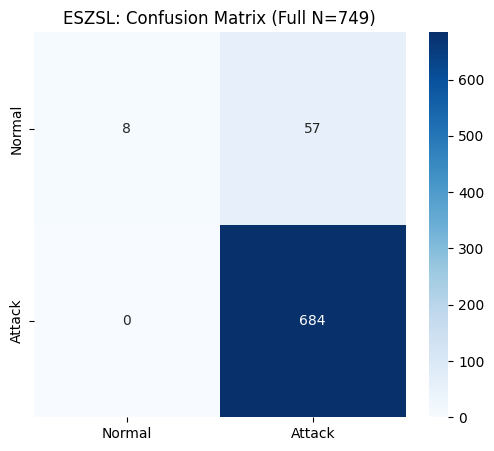

In [17]:
# Assuming 'model_eszsl' is your trained ESZSL_IOT class
data_test_pd = pd.DataFrame(data_test, columns=original_columns)
eszsl_results_df = eszsl_balanced_stress_test(
    data_test_pd,
    labels_test,
    model_eszsl,
    S_matrix,
    n_instances=50
)

# Save for your final comparison
eszsl_results_df.to_csv('UNR-IDD_ESZSL_Baseline_200_Results.csv', index=False)
print("ESZSL Stress Test Complete. Avg Latency:", eszsl_results_df['inf_ms'].mean())

In [24]:
#### DBERTa
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def zdberta_comprehensive_stress_test(X_test, y_test, zd_predictor, labels_text, n_instances=50):
    """
    Stress test for ZDBERTa (DeBERTa-v3-Large) using a 1,000-record sample
    to find a balanced 200-packet stress pool and generate a Confusion Matrix.
    """
    results = []

    print(f"Profiling ZDBERTa on {len(X_test)} records")
    all_multiclass_preds = zd_predictor.predict_batch(X_test, labels_text)

    # Map results to binary for Confusion Matrix and Stress Pool identification
    # (Assuming "Normal" is index 0 or strictly named "Normal")
    # Strip whitespace and lowercase to ensure a match
    binary_preds = np.array([0 if str(p).strip().capitalize() == "Normal" else 1 for p in all_multiclass_preds])
    #binary_preds = np.array([0 if p == "Normal" else 1 for p in all_multiclass_preds])
    binary_truth = np.where(y_test > 0, 1, 0)

    # --- ADDED: CONFUSION MATRIX GENERATION ---
    cm = confusion_matrix(binary_truth, binary_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    plt.title(f'ZDBERTa: Confusion Matrix (N={len(X_test)} Sample)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('ZDBERTa_1k_Confusion_Matrix.png')
    print("Confusion Matrix saved as 'ZDBERTa_1k_Confusion_Matrix.png'")
    # ------------------------------------------

    tp_indices = np.where((binary_preds == 1) & (binary_truth == 1))[0][:n_instances]
    tn_indices = np.where((binary_preds == 0) & (binary_truth == 0))[0][:n_instances]
    fp_indices = np.where((binary_preds == 1) & (binary_truth == 0))[0][:n_instances]
    fn_indices = np.where((binary_preds == 0) & (binary_truth == 1))[0][:n_instances]

    test_indices = np.concatenate([tp_indices, tn_indices, fp_indices, fn_indices])

    category_map = {idx: 'TP' for idx in tp_indices}
    category_map.update({idx: 'TN' for idx in tn_indices})
    category_map.update({idx: 'FP' for idx in fp_indices})
    category_map.update({idx: 'FN' for idx in fn_indices})

    print(f"Executing Detailed Stress Test on {len(test_indices)} packets...")

    # 3. Detailed Packet-by-Packet Analysis
    for idx in test_indices:
        instance = X_test.iloc[idx:idx+1]
        start_time = time.perf_counter()

        prediction = zd_predictor.predict_batch(instance, labels_text)[0]

        end_time = time.perf_counter()
        latency_ms = (end_time - start_time) * 1000

        results.append({
            'packet_index': idx,
            'ground_truth_binary': 'Attack' if y_test.iloc[idx] > 0 else 'Normal',
            'stress_category': category_map[idx],
            'zdberta_prediction': prediction,
            'inf_ms': latency_ms,
            'total_ms': latency_ms
        })

    return pd.DataFrame(results)

In [ ]:
original_columns = SDN_train_test_data.drop(columns=['Attack']).columns

In [ ]:
# --- EXECUTION ---
# Ensure your zdberta object and labels are initialized as provided in your prompt
data_test_pd = pd.DataFrame(data_test, columns=original_columns)

zdberta_results_df = zdberta_comprehensive_stress_test(data_test_pd, labels_test, zdberta, labels)
zdberta_results_df.to_csv('UNR-IDD_ZDBERTa_DeBERTa_200_Results_2.csv', index=False)

Profiling ZDBERTa on 749 records
